<a href="https://colab.research.google.com/github/deepanshuchauhanx1/AI-Traffic-Flow-Optimizer/blob/main/yolov8_emergency_vehicle_detection_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
cv2.getBuildInformation()

'\nGeneral configuration for OpenCV 4.13.0 =====================================\n  Version control:               4.13.0-1-gb4c5ec4042\n\n  Platform:\n    Timestamp:                   2026-02-05T07:45:09Z\n    Host:                        Linux 6.8.0-1044-azure x86_64\n    CMake:                       4.2.1\n    CMake generator:             Unix Makefiles\n    CMake build tool:            /bin/gmake\n    Configuration:               Release\n    Algorithm Hint:              ALGO_HINT_ACCURATE\n\n  CPU/HW features:\n    Baseline:                    SSE SSE2 SSE3\n      requested:                 SSE3\n    Dispatched code generation:  SSE4_1 SSE4_2 AVX FP16 AVX2 AVX512_SKX\n      SSE4_1 (17 files):         + SSSE3 SSE4_1\n      SSE4_2 (1 files):          + SSSE3 SSE4_1 POPCNT SSE4_2\n      AVX (9 files):             + SSSE3 SSE4_1 POPCNT SSE4_2 AVX\n      FP16 (0 files):            + SSSE3 SSE4_1 POPCNT SSE4_2 AVX FP16\n      AVX2 (37 files):           + SSSE3 SSE4_1 POPCNT SSE4_2 AVX F

In [15]:
train = pd.read_csv("/content/drive/MyDrive/ATIS Dataset/train/_classes.csv")
valid = pd.read_csv("/content/drive/MyDrive/ATIS Dataset/valid/_classes.csv")
test = pd.read_csv("/content/drive/MyDrive/ATIS Dataset/test/_classes.csv")

print(f"Shape of train: {train.shape}, valid: {valid.shape}, test: {test.shape}")

Shape of train: (8277, 8), valid: (624, 8), test: (476, 8)


In [16]:
# Clean column names by stripping whitespace
train.columns = train.columns.str.strip()
valid.columns = valid.columns.str.strip()
test.columns = test.columns.str.strip()

print(train.columns)

Index(['filename', 'TwoWheelers', 'ambulance', 'auto-rikshaw', 'bus', 'car',
       'firetruck', 'police vehicle'],
      dtype='object')


Convert one-hot labels to class names

In [47]:
classes = [
    "TwoWheelers",
    "ambulance",
    "auto-rikshaw",
    "bus",
    "car",
    "firetruck",
    "police vehicle"
]
def get_label(row):
    for c in classes:
        if row[c] == 1:
            return c
    return "unknown"

train["label"] = train.apply(get_label, axis=1)
valid["label"] = valid.apply(get_label, axis=1)
test["label"] = test.apply(get_label, axis=1)

Add dataset split column

In [19]:
train["split"] = "train"
valid["split"] = "valid"
test["split"] = "test"

df = pd.concat([train, valid, test], ignore_index=True)

In [20]:
df

,filename,TwoWheelers,ambulance,auto-rikshaw,bus,car,firetruck,police vehicle,label,split
0,129_jpg.rf.84859d4fc5818dc50d1f96b88b7efc36.jpg,0,0,0,0,0,1,0,firetruck,train
1,new-delhi-india-june-17-260nw-1758724742_jpg.r...,0,1,0,0,0,0,0,ambulance,train
2,ambulance-395-_jpg.rf.84890f639c23d72eba234cd0...,0,0,0,0,0,0,0,unknown,train
3,13_jpg.rf.8491319430ac3431e84d5c33468b30ac.jpg,0,0,0,0,0,0,0,unknown,train
4,ambulance-190-_jpg.rf.8499adab18f6dc139f642a2b...,0,0,0,0,0,0,0,unknown,train
...,...,...,...,...,...,...,...,...,...,...
9372,ambulance-408-_jpg.rf.fcd558f58c3b1186d256a745...,0,0,0,0,0,0,0,unknown,test
9373,15_jpg.rf.fc97869d7c1933a273f0f2ad578a28c7.jpg,0,0,0,0,0,1,0,firetruck,test
9374,Ambulance_used_by_Narayana_Health_Group-_India...,0,1,0,0,0,0,0,ambulance,test
9375,ambulance-348-_jpg.rf.fcbefc2fdb28c4b1214d9862...,0,0,0,0,0,0,0,unknown,test


In [21]:
print("Total Images:", len(df))
print(df["label"].value_counts())

Total Images: 9377
label
unknown           3132
ambulance         2742
police vehicle    1270
firetruck         1152
car                456
bus                257
TwoWheelers        252
auto-rikshaw       116
Name: count, dtype: int64


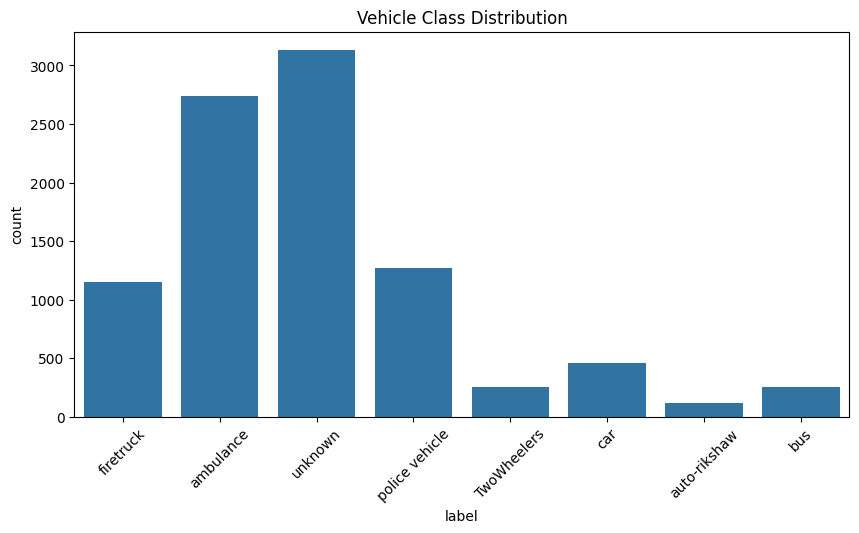

In [22]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="label")
plt.xticks(rotation=45)
plt.title("Vehicle Class Distribution")
plt.show()

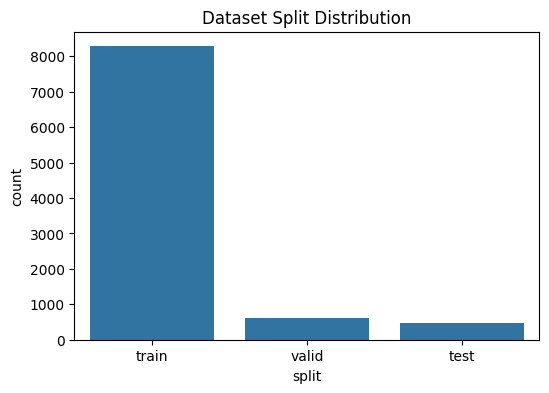

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="split")
plt.title("Dataset Split Distribution")
plt.show()

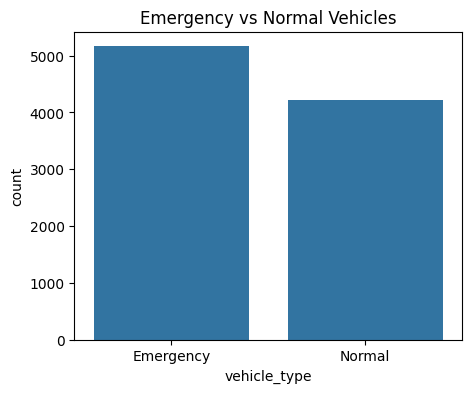

In [24]:
emergency = ["ambulance","firetruck","police vehicle"]

df["vehicle_type"] = df["label"].apply(
    lambda x: "Emergency" if x in emergency else "Normal"
)

plt.figure(figsize=(5,4))
sns.countplot(data=df, x="vehicle_type")
plt.title("Emergency vs Normal Vehicles")
plt.show()

In [25]:
percent = df["label"].value_counts(normalize=True) * 100
print(percent)

label
unknown           33.400874
ambulance         29.241762
police vehicle    13.543777
firetruck         12.285379
car                4.862963
bus                2.740749
TwoWheelers        2.687427
auto-rikshaw       1.237069
Name: proportion, dtype: float64


Removing Unknown

In [26]:
df = df[df["label"] != "unknown"]
df["label"].value_counts(normalize=True) * 100

,proportion
label,
ambulance,43.907126
police vehicle,20.336269
firetruck,18.446757
car,7.301841
bus,4.115292
TwoWheelers,4.035228
auto-rikshaw,1.857486


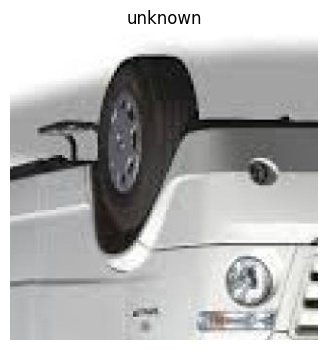

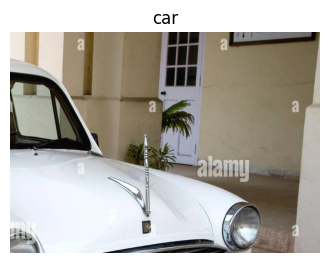

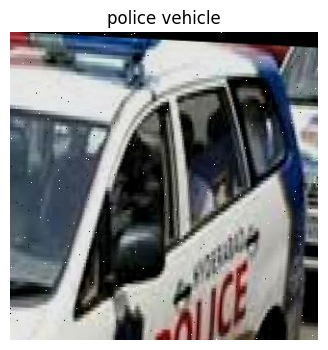

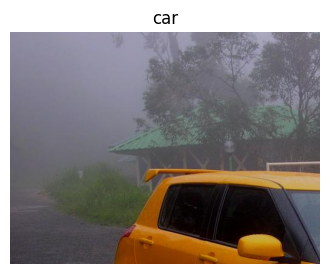

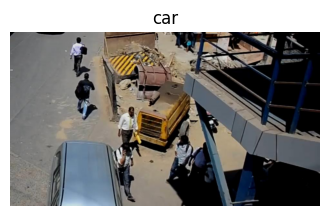

In [30]:
sample = train.sample(5)

for i,row in sample.iterrows():

    img_path = "/content/drive/MyDrive/ATIS Dataset/train/" + row["filename"]
    img = cv2.imread(img_path)

    if img is None:
        print("Image not found:", img_path)
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(row["label"])
    plt.axis("off")

In [29]:
sizes = []

for file in train["filename"][:200]:  # sample
    path = "/content/drive/MyDrive/ATIS Dataset/train/" + file
    img = cv2.imread(path)

    if img is not None:
        h,w,_ = img.shape
        sizes.append((w,h))

sizes = pd.DataFrame(sizes, columns=["width","height"])

sizes.describe()

,width,height
count,200.000000,200.000000
mean,354.330000,315.420000
std,196.623588,121.757084
min,112.000000,84.000000
25%,320.000000,320.000000
50%,320.000000,320.000000
75%,320.000000,320.000000
max,1000.000000,1000.000000


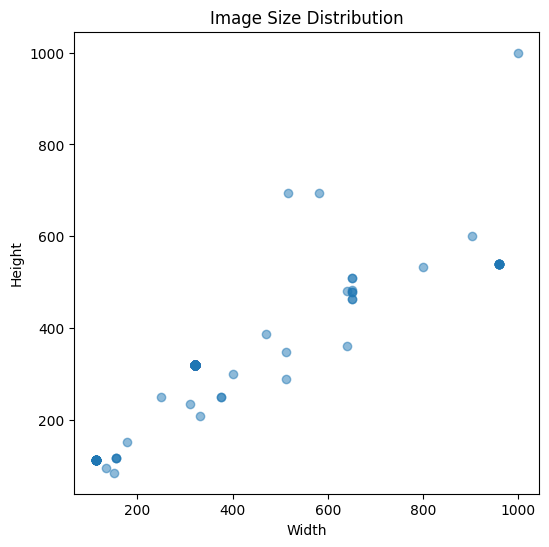

In [31]:
plt.figure(figsize=(6,6))
plt.scatter(sizes["width"], sizes["height"], alpha=0.5)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Size Distribution")
plt.show()

In [32]:
sizes["ratio"] = sizes["width"] / sizes["height"]

print(sizes["ratio"].describe())

count    200.000000
mean       1.094048
std        0.226094
min        0.743885
25%        1.000000
50%        1.000000
75%        1.000000
max        1.785714
Name: ratio, dtype: float64


In [33]:
#verify each row has exactly one class
train[classes].sum(axis=1).value_counts()

,count
1,5239
0,2765
2,162
3,90
4,15
5,6


In [41]:
!pip install ultralytics

In [ ]:
import os
import shutil


base_dir = "/content/drive/MyDrive/ATIS Dataset"
output_dir = "/content/drive/MyDrive/ATIS_dataset_cls"

splits = ["train", "valid", "test"]

for split in splits:

    csv_path = f"{base_dir}/{split}/_classes.csv"
    df = pd.read_csv(csv_path)

    # Clean column names again just to be safe
    df.columns = df.columns.str.strip()

    # Create class folders
    for cls in classes:
        os.makedirs(f"{output_dir}/{split}/{cls}", exist_ok=True)

    for _, row in df.iterrows():

        img_name = row["filename"]
        src = os.path.join(base_dir, split, img_name)

        for cls in classes:

            if row[cls] == 1:

                dst = os.path.join(output_dir, split, cls, img_name)

                if os.path.exists(src):
                    shutil.copy(src, dst)

In [43]:
print(os.listdir("/content/drive/MyDrive/ATIS_dataset_cls/train"))

['TwoWheelers', 'ambulance', 'auto-rikshaw', 'bus', 'car', 'firetruck', 'police vehicle']


In [45]:
from ultralytics import YOLO

model = YOLO("yolov8n-cls.pt")

model.train(
    data="/content/drive/MyDrive/ATIS_dataset_cls",
    epochs=50,
    imgsz=320,
    batch=16
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/ATIS_dataset_cls, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, img

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78b09028d0a0>
curves: []
curves_results: []
fitness: 0.9175824224948883
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.8351648449897766, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9175824224948883}
save_dir: PosixPath('/content/runs/classify/train')
speed: {'preprocess': 0.15815944176750607, 'inference': 0.623488654949412, 'loss': 0.0004265999930314617, 'postprocess': 0.0007130395645687643}
task: 'classify'
top1: 0.8351648449897766
top5: 1.0

In [48]:
import torch
print(torch.cuda.is_available())

True


In [49]:
model = YOLO("/content/runs/classify/train/weights/best.pt")

In [51]:
metrics = model.val(data="/content/drive/MyDrive/ATIS_dataset_cls")
print(metrics)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,443,847 parameters, 0 gradients, 3.3 GFLOPs
train: /content/drive/MyDrive/ATIS_dataset_cls/train... found 5923 images in 7 classes ✅ 
val: /content/drive/MyDrive/ATIS_dataset_cls/valid... found 455 images in 7 classes ✅ 
test: /content/drive/MyDrive/ATIS_dataset_cls/test... found 344 images in 7 classes ✅ 
val: Fast image access ✅ (ping: 0.7±0.3 ms, read: 7.9±7.6 MB/s, size: 18.7 KB)
val: Scanning /content/drive/MyDrive/ATIS_dataset_cls/valid... 455 images, 0 corrupt: 100% ━━━━━━━━━━━━ 455/455 212.0Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 29/29 4.2it/s 7.0s
                   all      0.833          1
Speed: 0.3ms preprocess, 1.2ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val
ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.me

In [52]:
print("Top-1 Accuracy:", metrics.top1)
print("Top-5 Accuracy:", metrics.top5)
print("Fitness Score:", metrics.fitness)

Top-1 Accuracy: 0.8329670429229736
Top-5 Accuracy: 1.0
Fitness Score: 0.9164835214614868


In [55]:
metrics.confusion_matrix.plot()

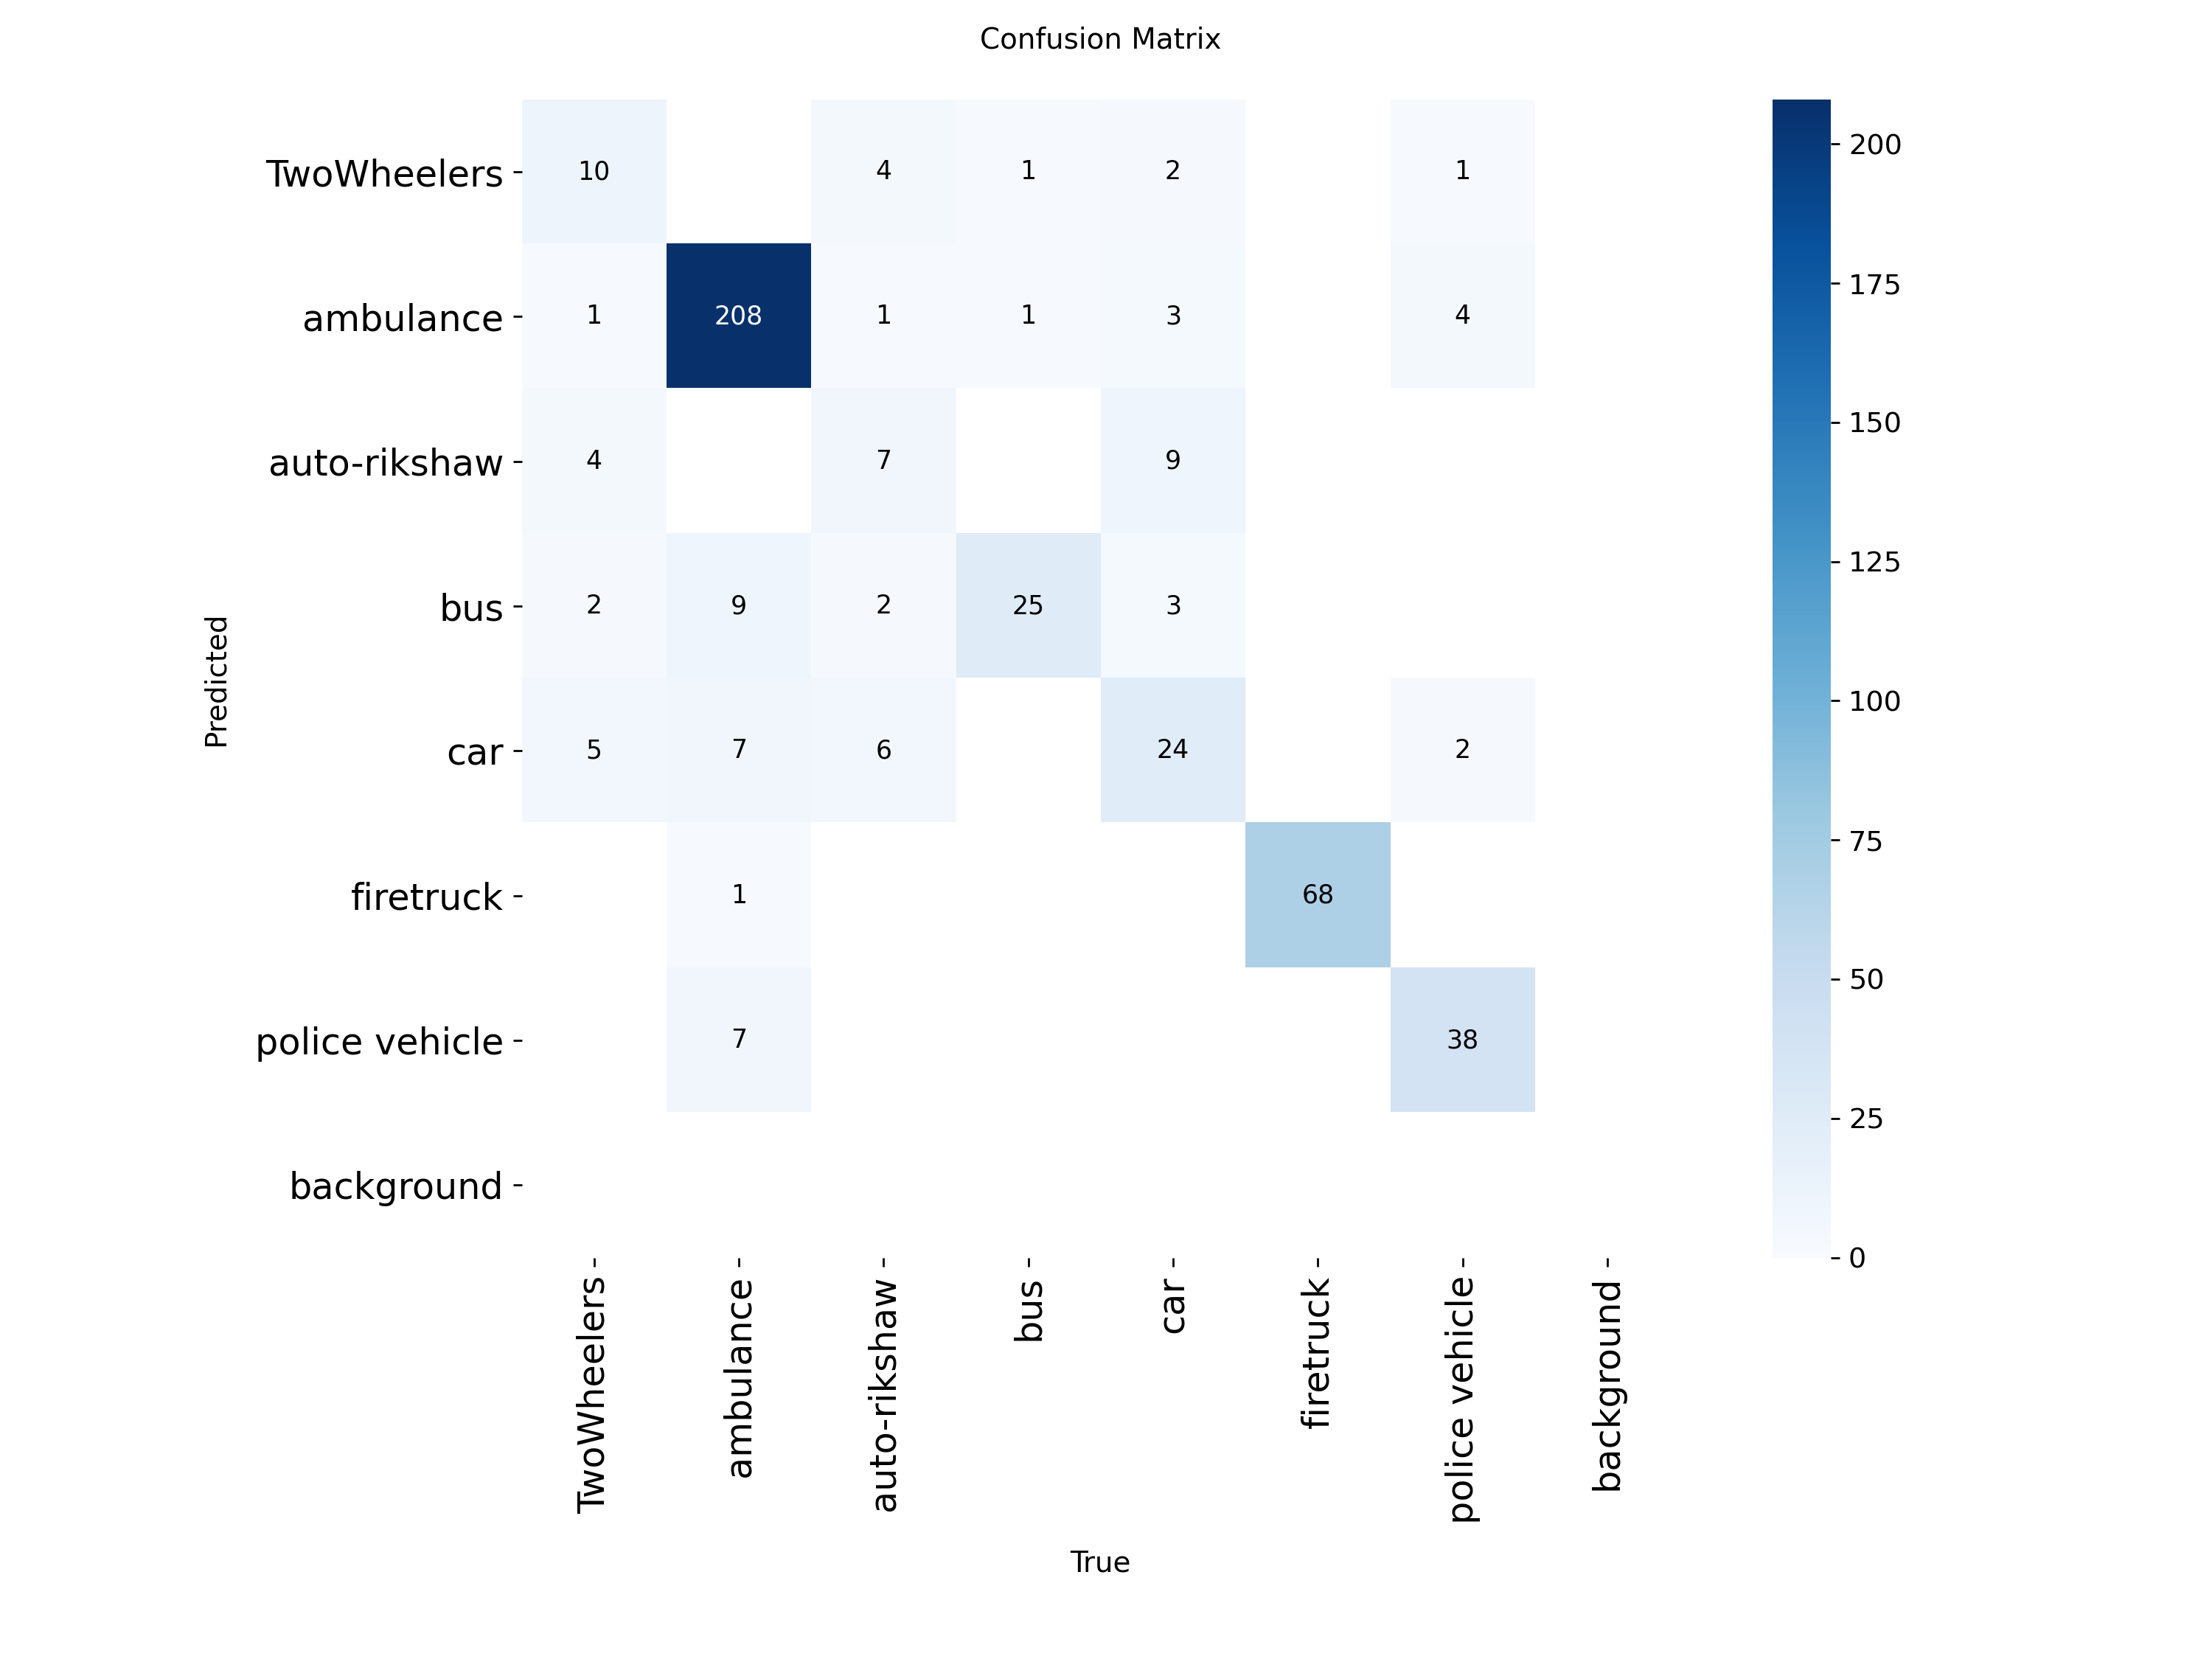

In [57]:
from IPython.display import Image
Image("/content/runs/classify/train/confusion_matrix.png")

In [58]:
metrics = model.val(data="/content/drive/MyDrive/ATIS_dataset_cls")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
train: /content/drive/MyDrive/ATIS_dataset_cls/train... found 5923 images in 7 classes ✅ 
val: /content/drive/MyDrive/ATIS_dataset_cls/valid... found 455 images in 7 classes ✅ 
test: /content/drive/MyDrive/ATIS_dataset_cls/test... found 344 images in 7 classes ✅ 
val: Fast image access ✅ (ping: 0.4±0.2 ms, read: 10.5±8.7 MB/s, size: 18.7 KB)
val: Scanning /content/drive/MyDrive/ATIS_dataset_cls/valid... 455 images, 0 corrupt: 100% ━━━━━━━━━━━━ 455/455 106.0Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 29/29 5.5it/s 5.3s
                   all      0.833          1
Speed: 0.2ms preprocess, 1.0ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val2


In [60]:
model = YOLO("/content/runs/classify/train/weights/best.pt")

In [62]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))

                precision    recall  f1-score   support

   TwoWheelers       0.40      0.33      0.36        12
     ambulance       0.95      0.81      0.87       129
  auto-rikshaw       0.33      0.36      0.34        14
           bus       0.44      0.75      0.56        20
           car       0.77      0.57      0.66        35
     firetruck       0.92      1.00      0.96        12
police vehicle       0.00      0.00      0.00         0

      accuracy                           0.72       222
     macro avg       0.54      0.55      0.54       222
  weighted avg       0.80      0.72      0.75       222



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [64]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.7207207207207207
Precision: 0.8029451911804852
Recall: 0.7207207207207207
F1 Score: 0.7524366476601506


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
